<a href="https://www.kaggle.com/code/lalit7881/anime-dataset-ratings-genres-popularity-eda?scriptVersionId=317777425" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nalisha/anime-dataset-ratings-genres-and-popularity/anime_dataset.csv


## Loading dataset


In [2]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/anime-dataset-ratings-genres-and-popularity/anime_dataset.csv")

In [3]:
df.head()

,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


In [4]:
df.tail()

,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
30070,64004,Manzoku desu,NaN,満足です,Music,Original,1.0,Finished Airing,False,2026-04-01,...,NaN,NaN,NaN,NaN,NaN,NaN,Music,Kids,Music video for the song Manzoku desu by Georg...,https://myanimelist.net/images/anime/1392/1569...
30071,64005,Overlay,NaN,オーバーレイ,Music,Original,1.0,Finished Airing,False,2026-04-01,...,NaN,NaN,NaN,NaN,NaN,NaN,Music,Kids,"Music video for the song Overlay by NILFRUITS,...",https://myanimelist.net/images/anime/1257/1569...
30072,64006,"Megane, Tokidoki, Yankee-kun",NaN,メガネ、時々、ヤンキーくん,TV,Manga,NaN,Not yet aired,False,NaN,...,NaN,NaN,NaN,NaN,NaN,Comedy|Romance,School,Shoujo,"In middle school, Hiro Momose was bullied and ...",https://myanimelist.net/images/anime/1839/1569...
30073,64012,The Ribbon Hero,The Ribbon Hero,THE RIBBON HERO リボンヒーロー,ONA,Manga,1.0,Not yet aired,False,2026-08-01,...,NaN,NaN,Outline,Twin Engine,NaN,Action|Adventure|Drama|Fantasy|Romance,Crossdressing,Shoujo,NaN,https://myanimelist.net/images/anime/1504/1570...
30074,64012,The Ribbon Hero,The Ribbon Hero,THE RIBBON HERO リボンヒーロー,ONA,Manga,1.0,Not yet aired,False,2026-08-01,...,NaN,NaN,Outline,Twin Engine,NaN,Action|Adventure|Drama|Fantasy|Romance,Crossdressing,Shoujo,NaN,https://myanimelist.net/images/anime/1504/1570...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30075 entries, 0 to 30074
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mal_id          30075 non-null  int64  
 1   title           30075 non-null  object 
 2   title_english   13306 non-null  object 
 3   title_japanese  29951 non-null  object 
 4   type            30003 non-null  object 
 5   source          30075 non-null  object 
 6   episodes        29236 non-null  float64
 7   status          30075 non-null  object 
 8   airing          30075 non-null  bool   
 9   aired_from      29166 non-null  object 
 10  aired_to        11594 non-null  object 
 11  duration        30075 non-null  object 
 12  rating          29473 non-null  object 
 13  score           19892 non-null  float64
 14  scored_by       19892 non-null  float64
 15  rank            22584 non-null  float64
 16  popularity      30075 non-null  int64  
 17  members         30075 non-null 

In [6]:
df.describe()

,mal_id,episodes,score,scored_by,rank,popularity,members,favorites,year
count,30075.000000,29236.000000,19892.00000,1.989200e+04,22584.000000,30075.000000,3.007500e+04,30075.000000,6525.000000
mean,35019.558537,13.958886,6.42559,2.969837e+04,11275.337894,14957.319501,3.901396e+04,429.132801,2010.646130
std,19983.466507,47.334180,0.89078,1.225328e+05,6508.725236,8634.251988,1.693139e+05,4550.008408,13.294049
min,1.000000,1.000000,1.89000,1.010000e+02,1.000000,1.000000,0.000000e+00,0.000000,1961.000000
25%,16833.000000,1.000000,5.80000,3.180000e+02,5636.750000,7483.000000,2.430000e+02,0.000000,2005.000000
50%,38852.000000,2.000000,6.41000,1.456000e+03,11275.000000,14946.000000,1.088000e+03,1.000000,2014.000000
75%,52131.500000,13.000000,7.07000,9.676250e+03,16909.250000,22428.000000,9.307500e+03,17.000000,2021.000000
max,64012.000000,3000.000000,9.27000,3.060289e+06,22548.000000,29935.000000,4.348557e+06,251194.000000,2027.000000


In [7]:
df.isnull().sum()

mal_id                0
title                 0
title_english     16769
title_japanese      124
type                 72
source                0
episodes            839
status                0
airing                0
aired_from          909
aired_to          18481
duration              0
rating              602
score             10183
scored_by         10183
rank               7491
popularity            0
members               0
favorites             0
season            23550
year              23550
studios           11938
producers         15796
licensors         24877
genres             6394
themes            12098
demographics      18941
synopsis           5038
image_url             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(139)

In [9]:

df.columns

Index(['mal_id', 'title', 'title_english', 'title_japanese', 'type', 'source',
       'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration',
       'rating', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'season', 'year', 'studios', 'producers', 'licensors',
       'genres', 'themes', 'demographics', 'synopsis', 'image_url'],
      dtype='object')

In [10]:
df.dtypes

mal_id              int64
title              object
title_english      object
title_japanese     object
type               object
source             object
episodes          float64
status             object
airing               bool
aired_from         object
aired_to           object
duration           object
rating             object
score             float64
scored_by         float64
rank              float64
popularity          int64
members             int64
favorites           int64
season             object
year              float64
studios            object
producers          object
licensors          object
genres             object
themes             object
demographics       object
synopsis           object
image_url          object
dtype: object

In [11]:
df.shape

(30075, 29)

In [12]:
df.nunique()

mal_id            29936
title             29934
title_english     13035
title_japanese    28739
type                  9
source               17
episodes            262
status                3
airing                2
aired_from         9560
aired_to           5721
duration            344
rating                6
score               569
scored_by          9450
rank              17434
popularity        23973
members           12598
favorites          2030
season                4
year                 67
studios            2019
producers          5511
licensors           303
genres              860
themes             1057
demographics          8
synopsis          24616
image_url         29740
dtype: int64

## EDA

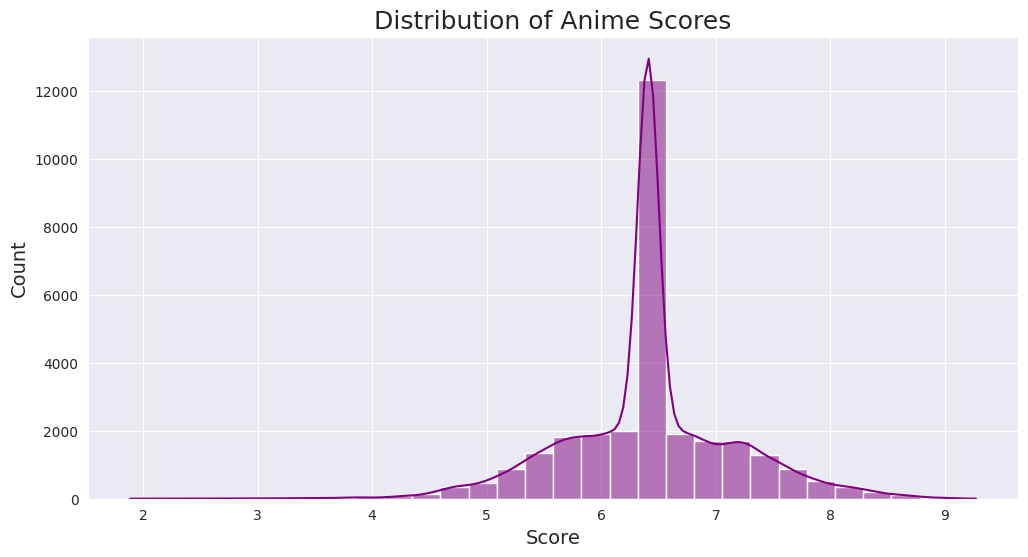

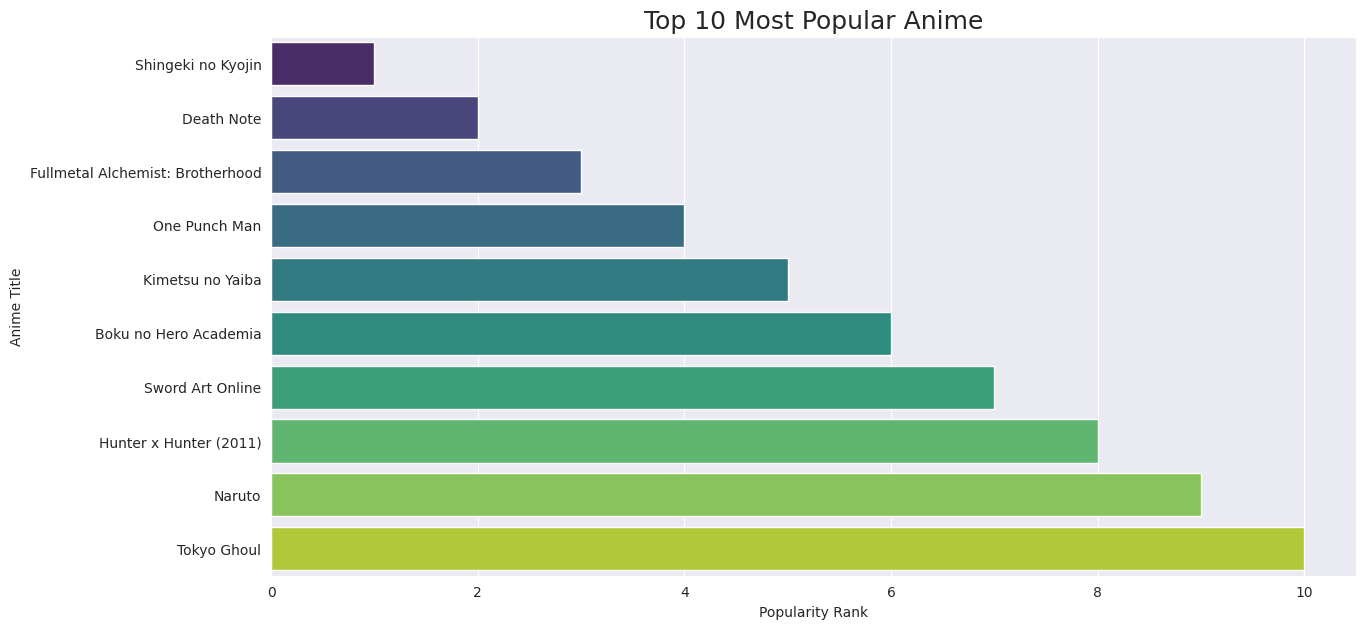

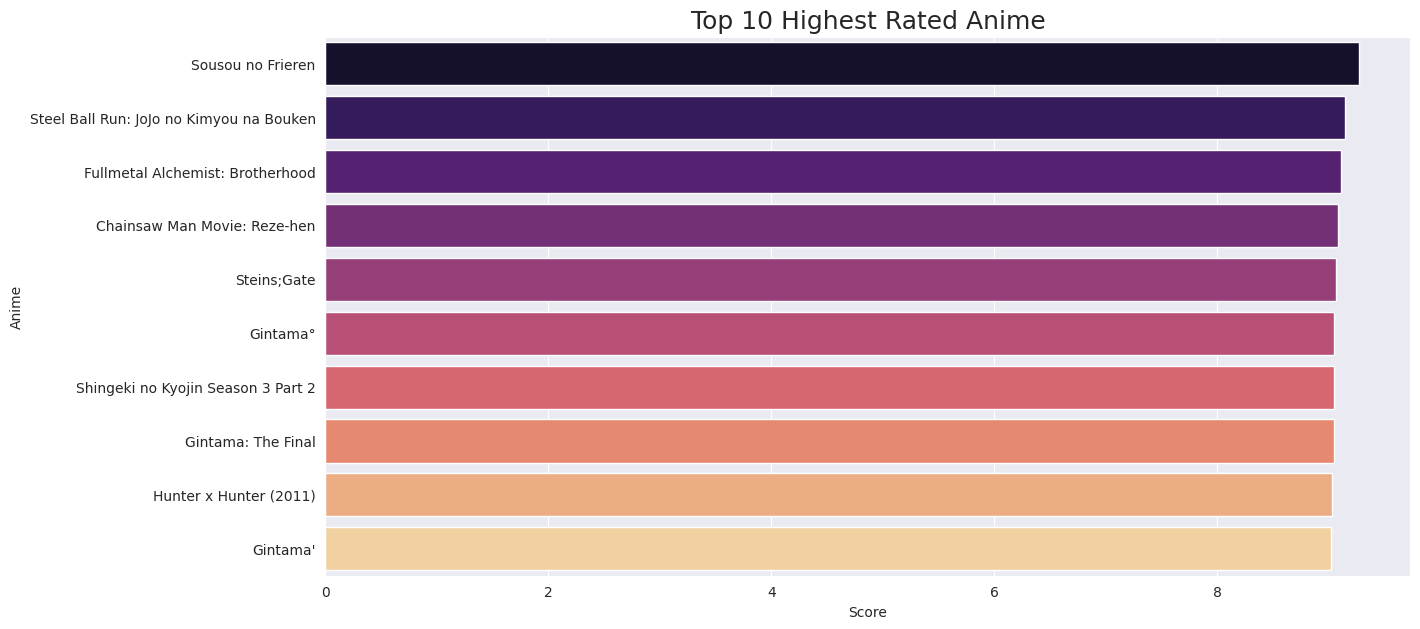

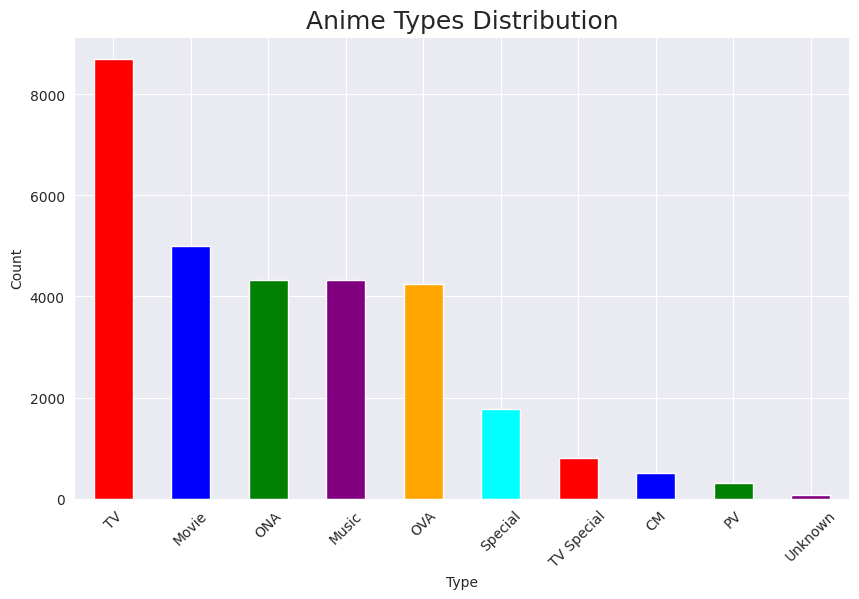

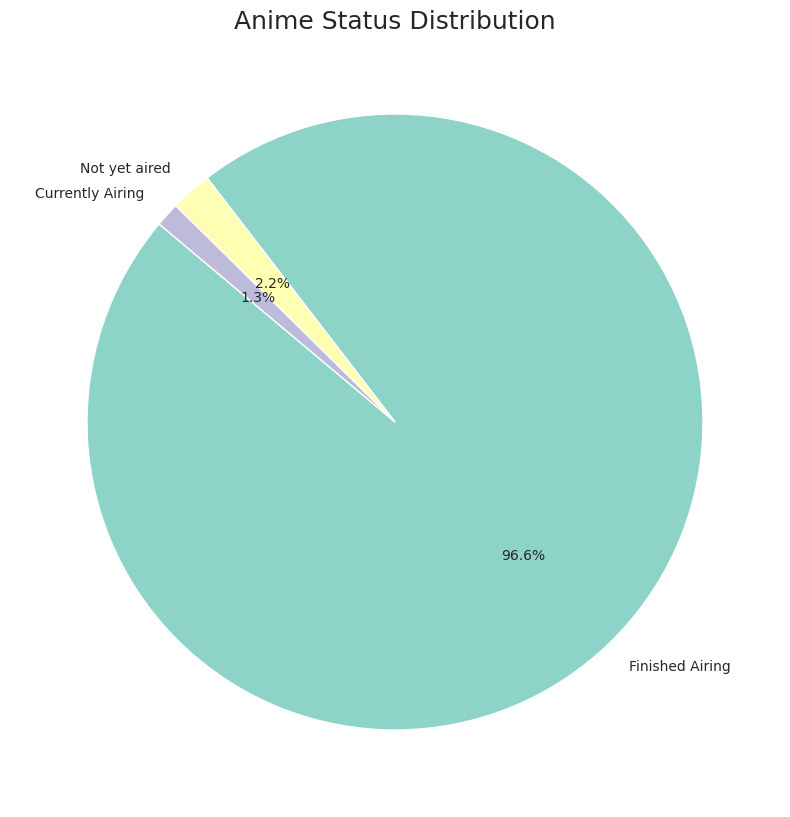

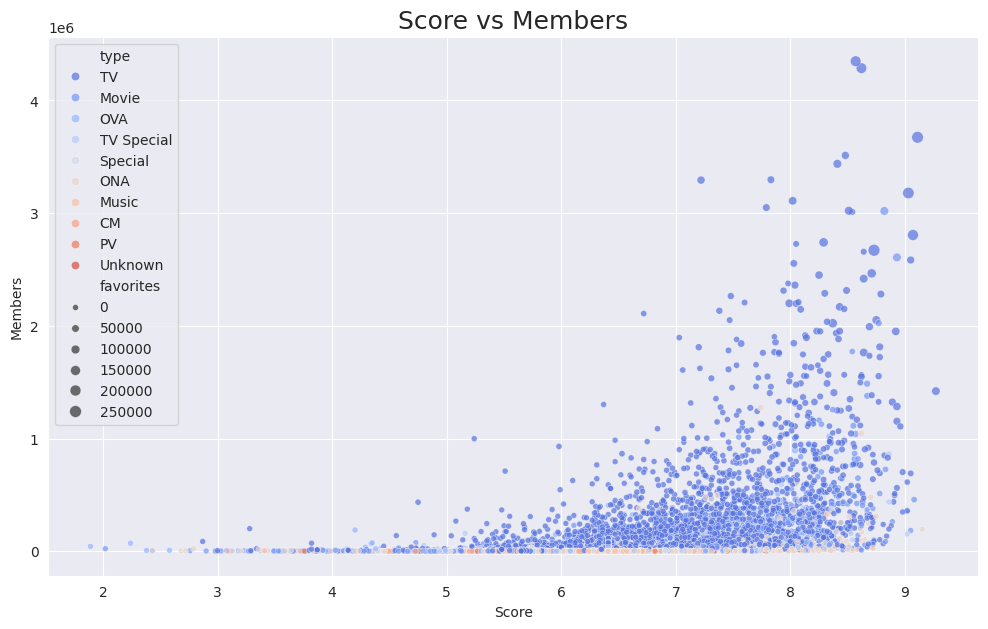

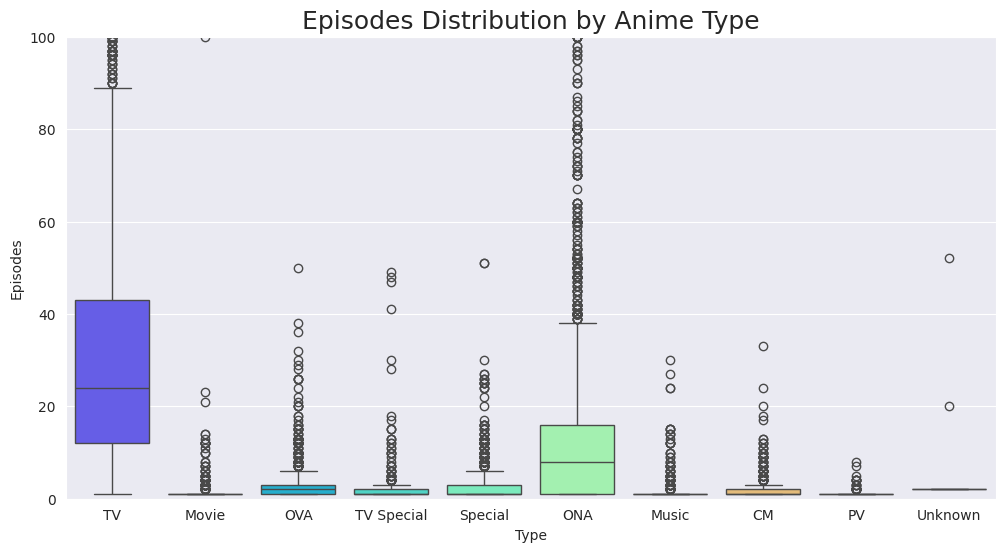

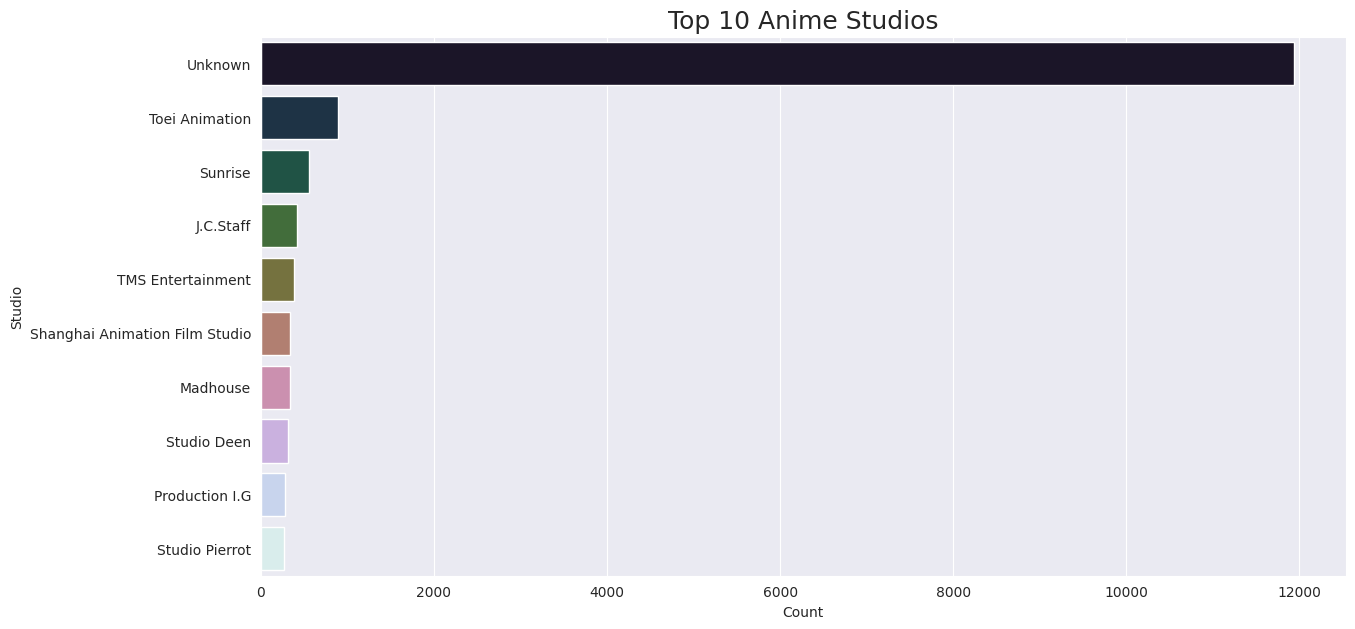

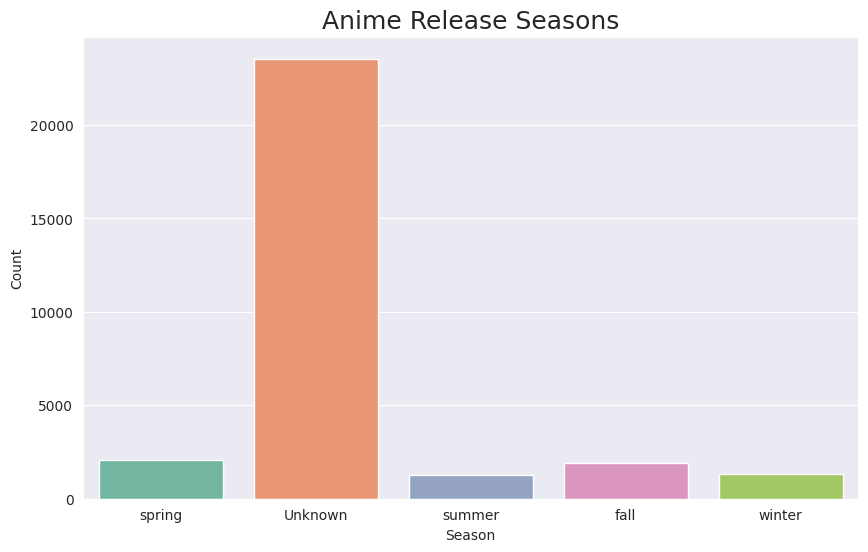

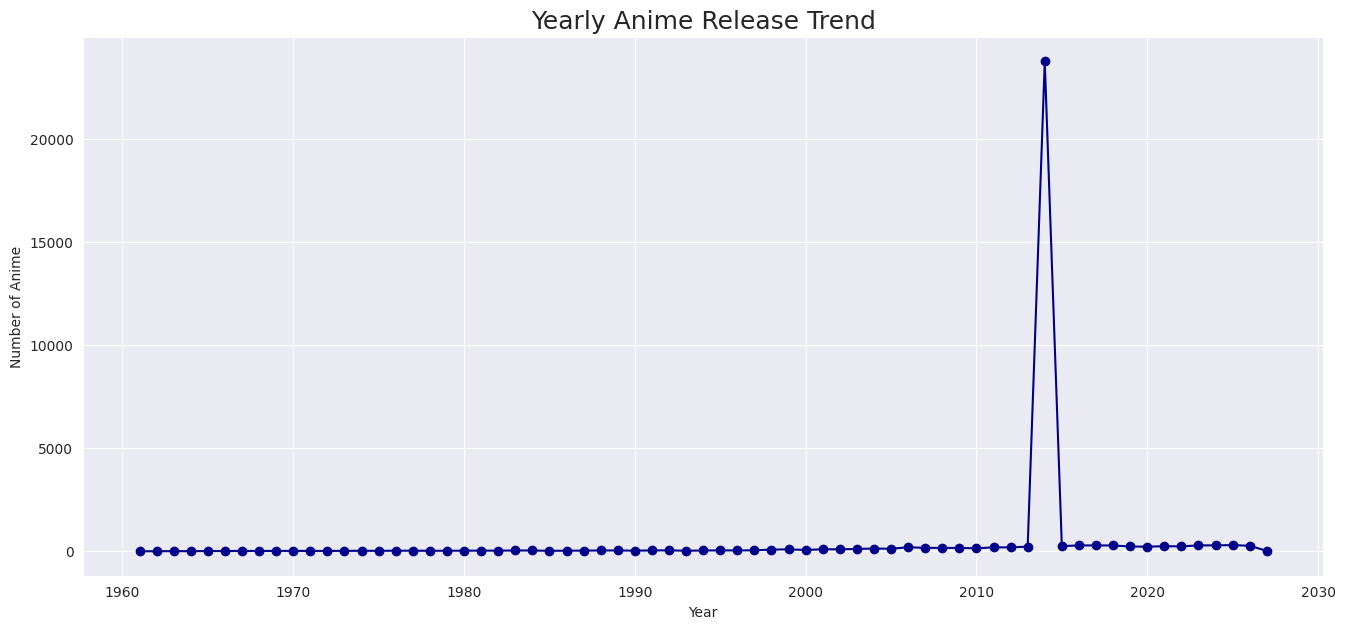

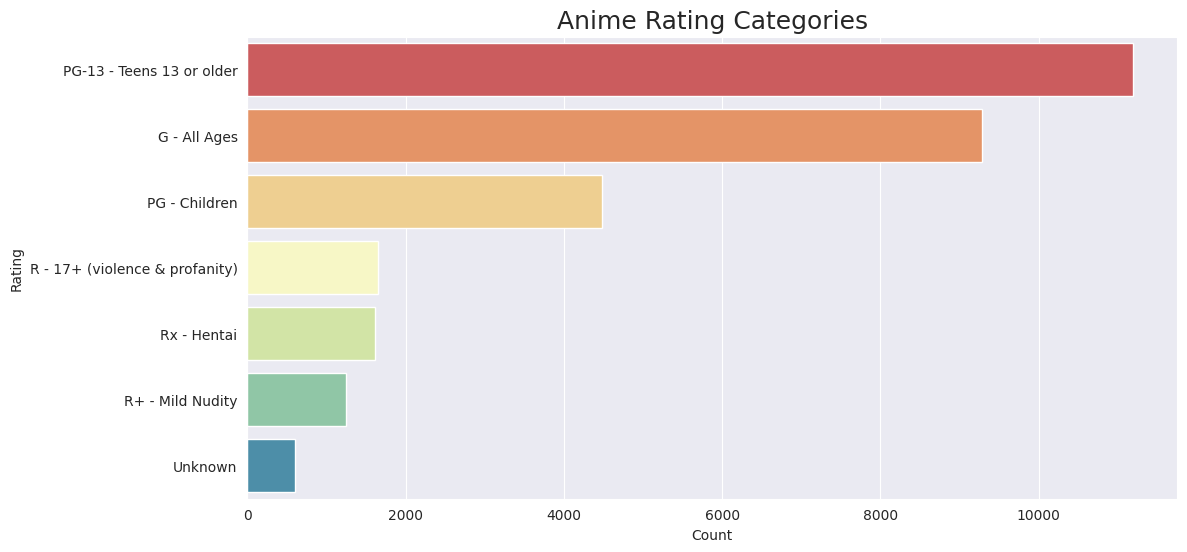

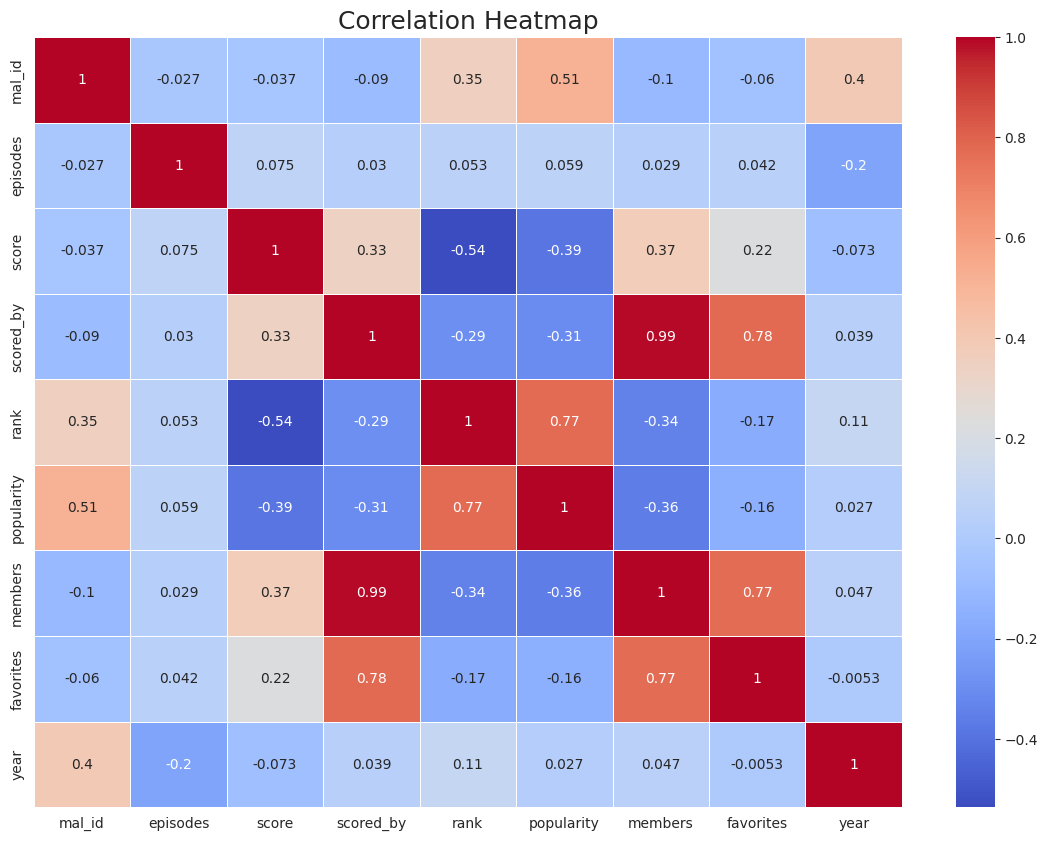

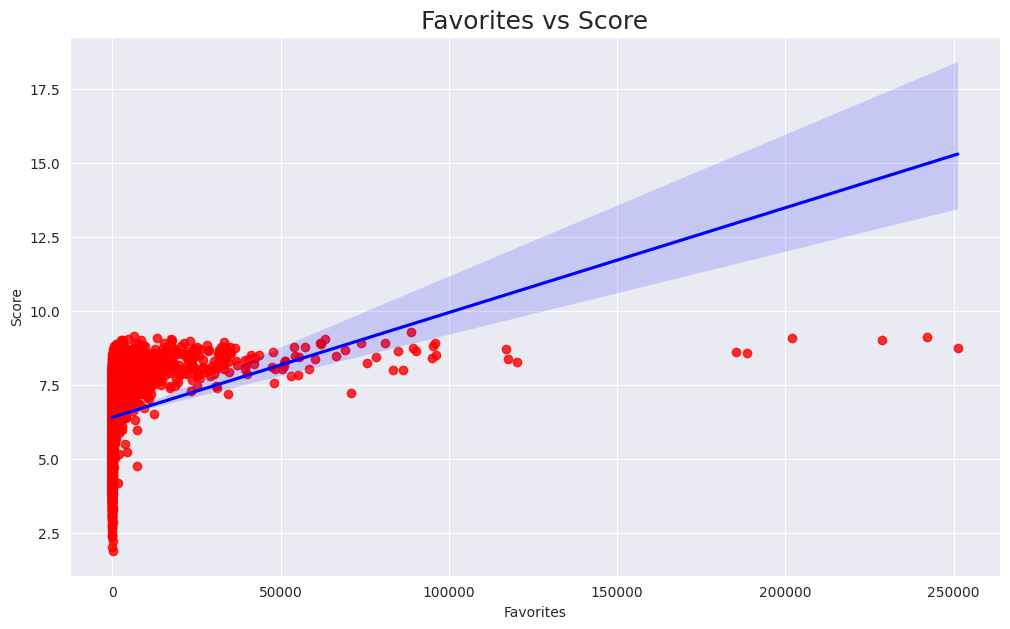

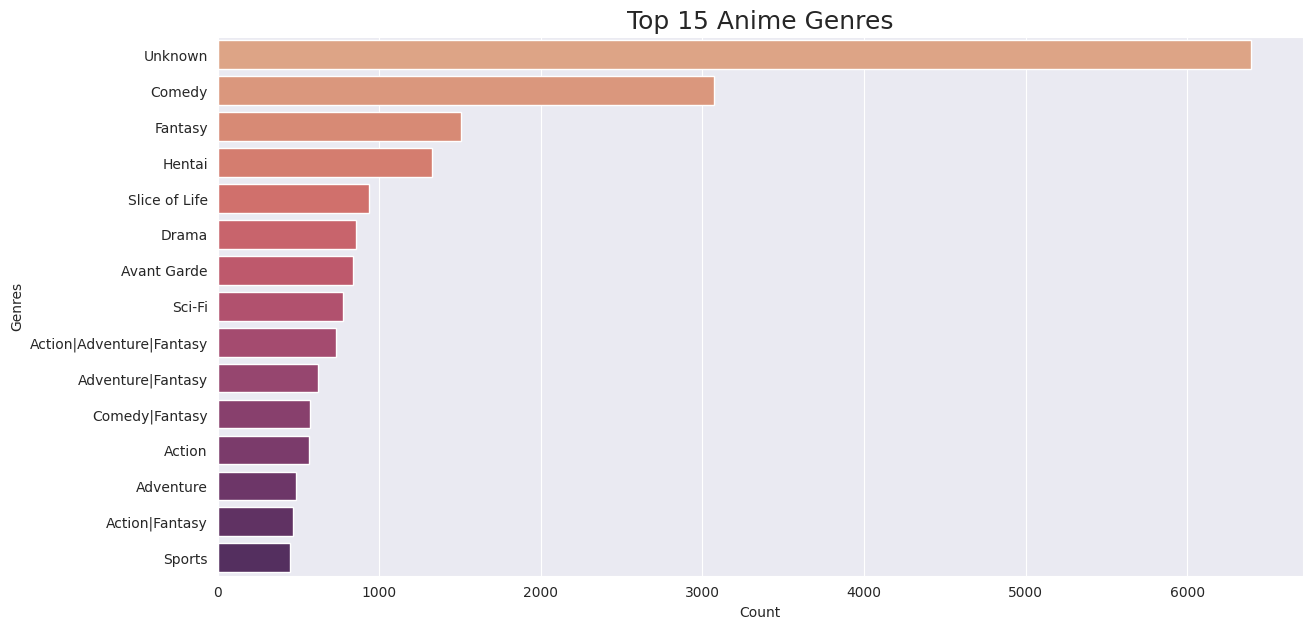

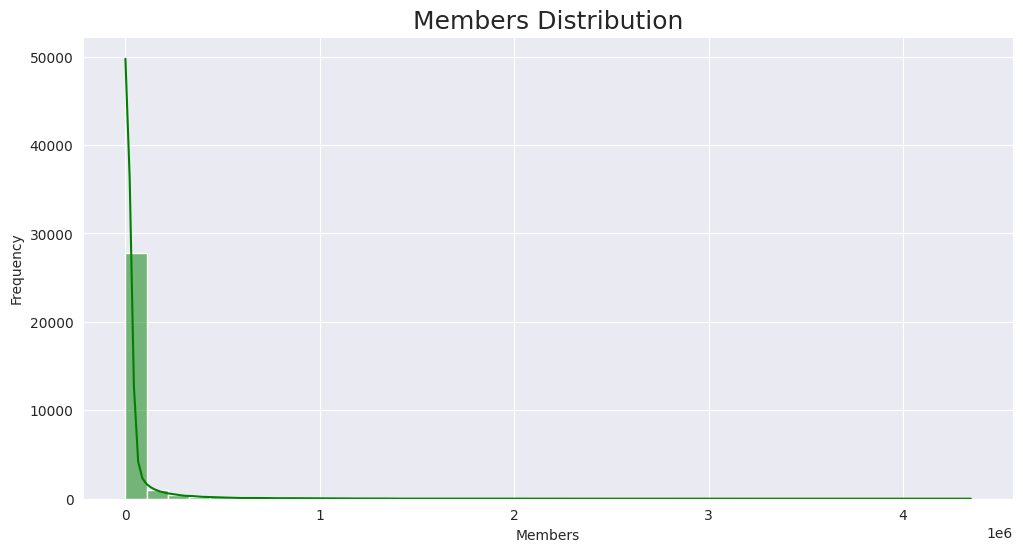

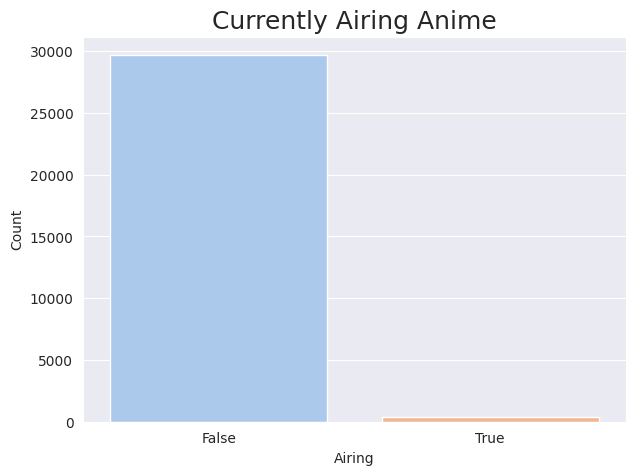

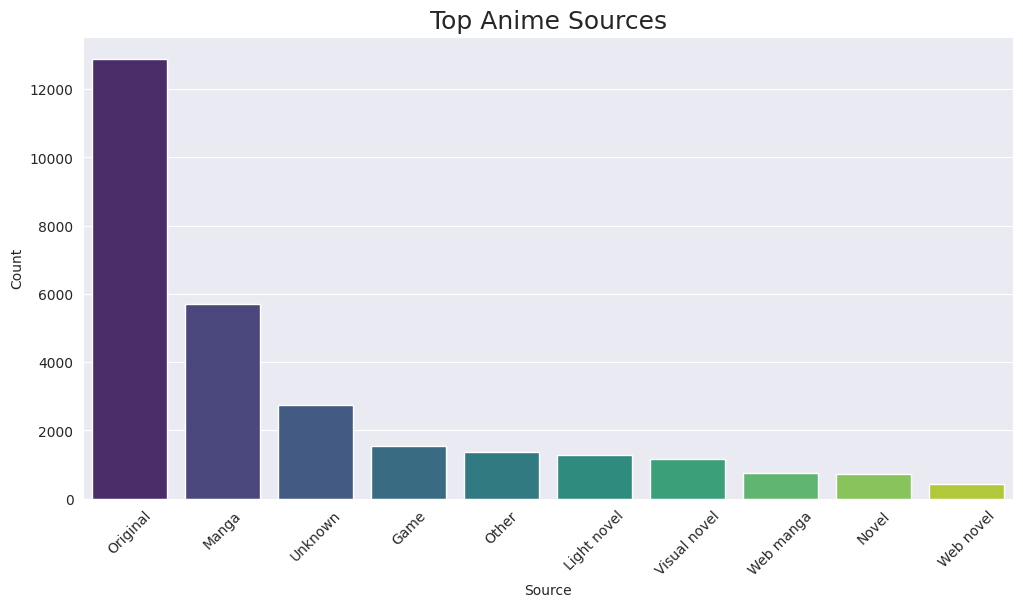

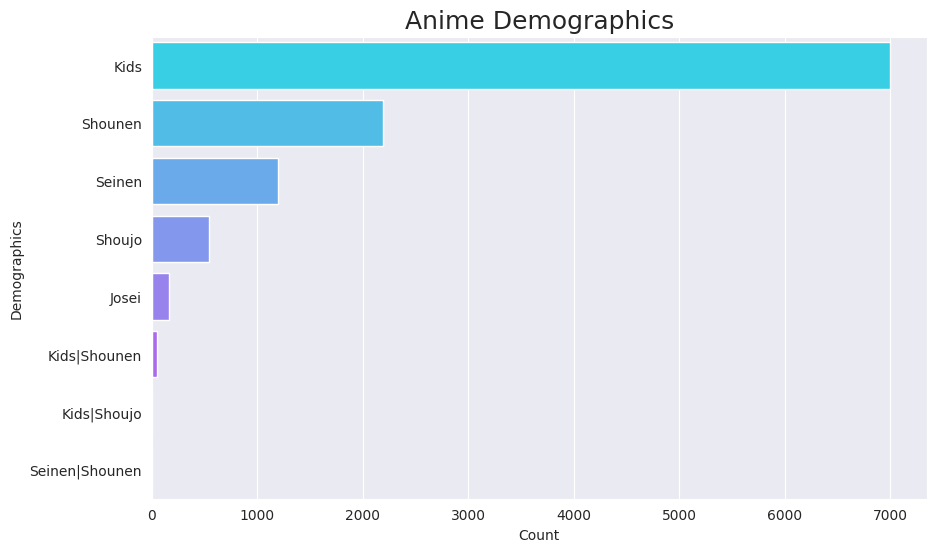

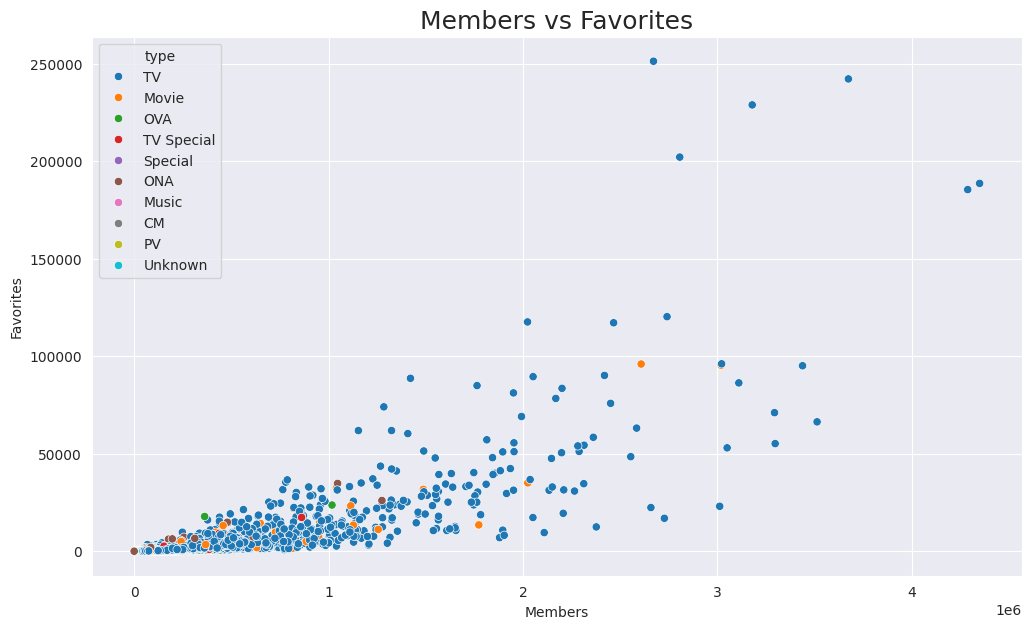

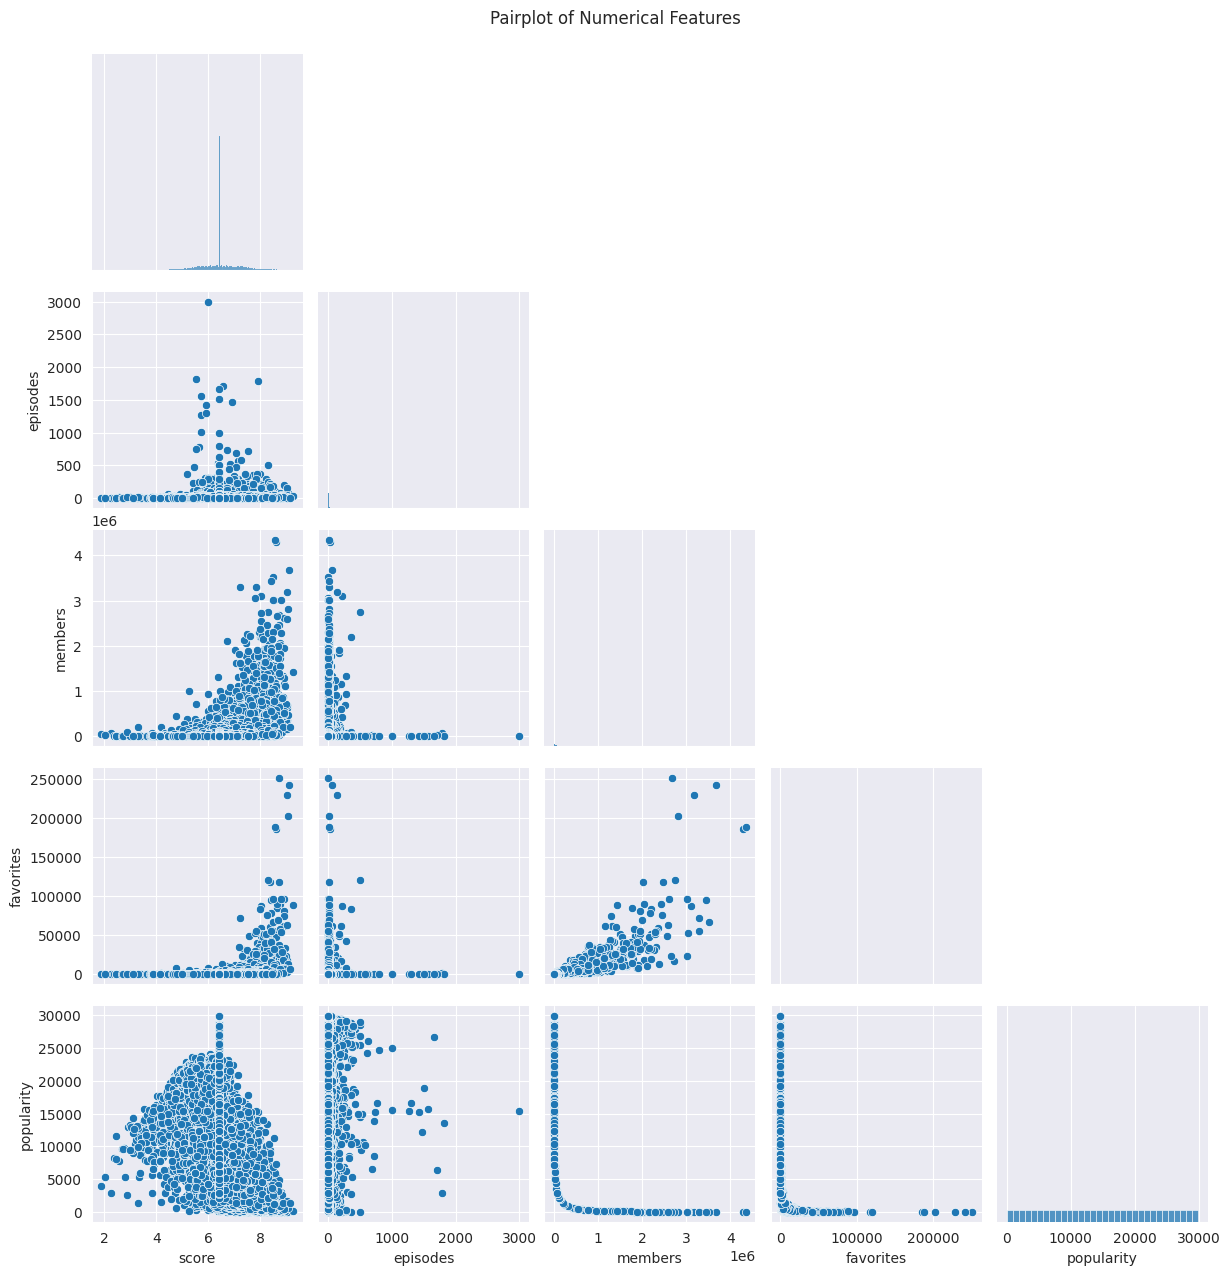


ALL VISUALIZATIONS COMPLETED SUCCESSFULLY


In [13]:
# Convert dates
df['aired_from'] = pd.to_datetime(df['aired_from'], errors='coerce')
df['aired_to'] = pd.to_datetime(df['aired_to'], errors='coerce')

# Fill missing numerical values
num_cols = ['episodes', 'score', 'scored_by', 'rank',
            'popularity', 'members', 'favorites', 'year']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
cat_cols = ['type', 'source', 'status', 'rating',
            'season', 'studios', 'genres']

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

# ==============================
# SET STYLE
# ==============================

sns.set_style("darkgrid")

# ==========================================================
# 1. DISTRIBUTION OF ANIME SCORES
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='score',
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Distribution of Anime Scores", fontsize=18)
plt.xlabel("Score", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# ==========================================================
# 2. TOP 10 MOST POPULAR ANIME
# ==========================================================

top_popular = df.sort_values(by='popularity').head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x='popularity',
    y='title',
    data=top_popular,
    palette='viridis'
)

plt.title("Top 10 Most Popular Anime", fontsize=18)
plt.xlabel("Popularity Rank")
plt.ylabel("Anime Title")

plt.show()

# ==========================================================
# 3. TOP 10 HIGHEST SCORED ANIME
# ==========================================================

top_score = df.sort_values(by='score', ascending=False).head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x='score',
    y='title',
    data=top_score,
    palette='magma'
)

plt.title("Top 10 Highest Rated Anime", fontsize=18)
plt.xlabel("Score")
plt.ylabel("Anime")

plt.show()

# ==========================================================
# 4. ANIME TYPES COUNT
# ==========================================================

plt.figure(figsize=(10,6))

df['type'].value_counts().plot(
    kind='bar',
    color=['red','blue','green','purple','orange','cyan']
)

plt.title("Anime Types Distribution", fontsize=18)
plt.xlabel("Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# 5. STATUS DISTRIBUTION PIE CHART
# ==========================================================

status_counts = df['status'].value_counts()

plt.figure(figsize=(10,10))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3'),
    startangle=140
)

plt.title("Anime Status Distribution", fontsize=18)

plt.show()

# ==========================================================
# 6. SCORE VS POPULARITY
# ==========================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='score',
    y='members',
    hue='type',
    size='favorites',
    data=df,
    palette='coolwarm',
    alpha=0.7
)

plt.title("Score vs Members", fontsize=18)
plt.xlabel("Score")
plt.ylabel("Members")

plt.show()

# ==========================================================
# 7. EPISODES DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='type',
    y='episodes',
    data=df,
    palette='rainbow'
)

plt.title("Episodes Distribution by Anime Type", fontsize=18)
plt.xlabel("Type")
plt.ylabel("Episodes")

plt.ylim(0, 100)

plt.show()

# ==========================================================
# 8. TOP STUDIOS
# ==========================================================

top_studios = df['studios'].value_counts().head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_studios.values,
    y=top_studios.index,
    palette='cubehelix'
)

plt.title("Top 10 Anime Studios", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Studio")

plt.show()

# ==========================================================
# 9. SEASON DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='season',
    data=df,
    palette='Set2'
)

plt.title("Anime Release Seasons", fontsize=18)
plt.xlabel("Season")
plt.ylabel("Count")

plt.show()

# ==========================================================
# 10. YEARLY ANIME RELEASE TREND
# ==========================================================

year_data = df['year'].value_counts().sort_index()

plt.figure(figsize=(16,7))

plt.plot(
    year_data.index,
    year_data.values,
    marker='o',
    linestyle='-',
    color='darkblue'
)

plt.title("Yearly Anime Release Trend", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Number of Anime")

plt.grid(True)

plt.show()

# ==========================================================
# 11. TOP RATINGS CATEGORY
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index,
    palette='Spectral'
)

plt.title("Anime Rating Categories", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

# ==========================================================
# 12. CORRELATION HEATMAP
# ==========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

# ==========================================================
# 13. FAVORITES VS SCORE
# ==========================================================

plt.figure(figsize=(12,7))

sns.regplot(
    x='favorites',
    y='score',
    data=df,
    scatter_kws={'color':'red'},
    line_kws={'color':'blue'}
)

plt.title("Favorites vs Score", fontsize=18)
plt.xlabel("Favorites")
plt.ylabel("Score")

plt.show()

# ==========================================================
# 14. TOP GENRES
# ==========================================================

genre_series = df['genres'].dropna().str.split(', ').explode()

top_genres = genre_series.value_counts().head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='flare'
)

plt.title("Top 15 Anime Genres", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Genres")

plt.show()

# ==========================================================
# 15. MEMBERS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['members'],
    bins=40,
    color='green',
    kde=True
)

plt.title("Members Distribution", fontsize=18)
plt.xlabel("Members")
plt.ylabel("Frequency")

plt.show()

# ==========================================================
# 16. AIRING VS NON-AIRING ANIME
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='airing',
    data=df,
    palette='pastel'
)

plt.title("Currently Airing Anime", fontsize=18)
plt.xlabel("Airing")
plt.ylabel("Count")

plt.show()

# ==========================================================
# 17. SOURCE MATERIAL DISTRIBUTION
# ==========================================================

top_sources = df['source'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sources.index,
    y=top_sources.values,
    palette='viridis'
)

plt.title("Top Anime Sources", fontsize=18)
plt.xlabel("Source")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# 18. DEMOGRAPHICS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    y='demographics',
    data=df,
    order=df['demographics'].value_counts().index,
    palette='cool'
)

plt.title("Anime Demographics", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Demographics")

plt.show()

# ==========================================================
# 19. MEMBERS VS FAVORITES
# ==========================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='members',
    y='favorites',
    hue='type',
    palette='tab10',
    data=df
)

plt.title("Members vs Favorites", fontsize=18)
plt.xlabel("Members")
plt.ylabel("Favorites")

plt.show()

# ==========================================================
# 20. PAIRPLOT
# ==========================================================

selected_cols = [
    'score',
    'episodes',
    'members',
    'favorites',
    'popularity'
]

sns.pairplot(
    df[selected_cols],
    corner=True
)

plt.suptitle("Pairplot of Numerical Features", y=1.02)

plt.show()

# ==========================================================
# FINAL MESSAGE
# ==========================================================

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY")
print("="*60)

## Feature engineering


TARGET VALUE COUNTS
target
0    27768
1     2307
Name: count, dtype: int64

Feature Shape : (30075, 21)
Target Shape  : (30075,)

NUMERICAL COLUMNS
Index(['episodes', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'year'],
      dtype='object')

CATEGORICAL COLUMNS
Index(['type', 'source', 'status', 'airing', 'duration', 'rating', 'season',
       'studios', 'producers', 'licensors', 'genres', 'themes',
       'demographics'],
      dtype='object')

TRAIN TEST SPLIT
X_train : (24060, 21)
X_test  : (6015, 21)
y_train : (24060,)
y_test  : (6015,)

Logistic Regression

Accuracy Score : 0.9945

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5554
           1       0.97      0.96      0.96       461

    accuracy                           0.99      6015
   macro avg       0.98      0.98      0.98      6015
weighted avg       0.99      0.99      0.99      6015



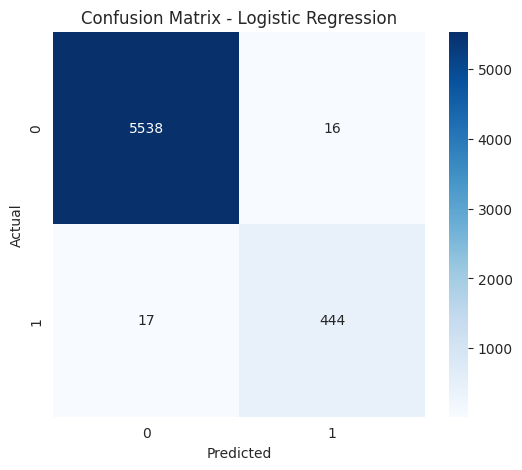

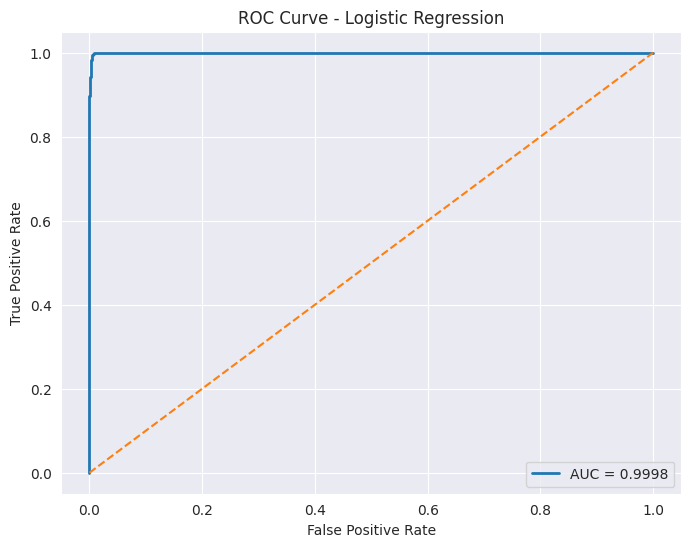


Decision Tree

Accuracy Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5554
           1       1.00      1.00      1.00       461

    accuracy                           1.00      6015
   macro avg       1.00      1.00      1.00      6015
weighted avg       1.00      1.00      1.00      6015



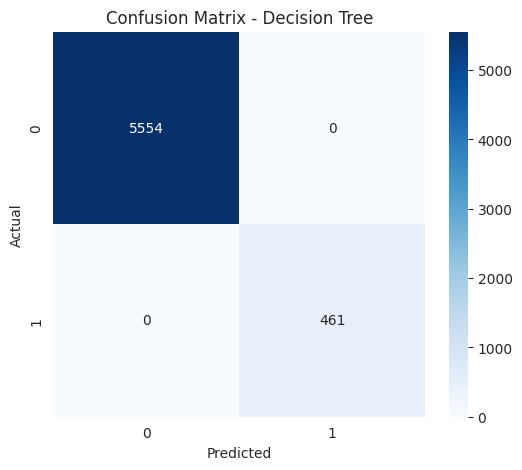

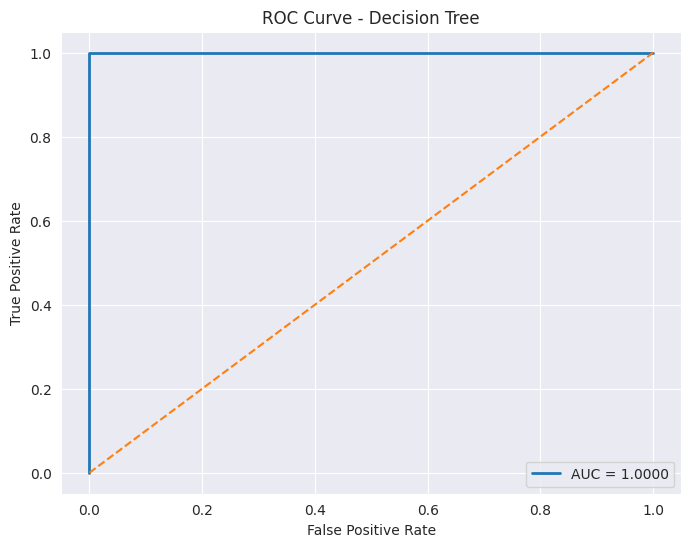


Random Forest

Accuracy Score : 0.9985

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5554
           1       1.00      0.98      0.99       461

    accuracy                           1.00      6015
   macro avg       1.00      0.99      0.99      6015
weighted avg       1.00      1.00      1.00      6015



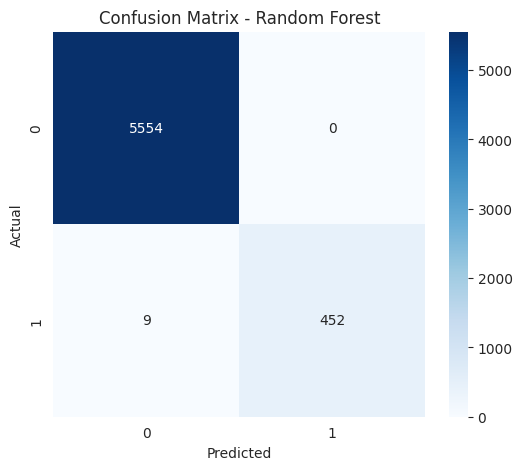

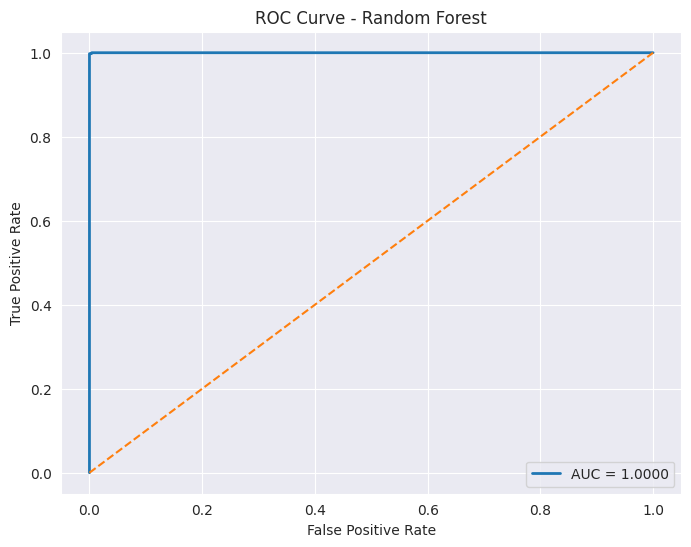


Naive Bayes

Accuracy Score : 0.5069

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.48      0.64      5554
           1       0.11      0.81      0.20       461

    accuracy                           0.51      6015
   macro avg       0.54      0.65      0.42      6015
weighted avg       0.90      0.51      0.61      6015



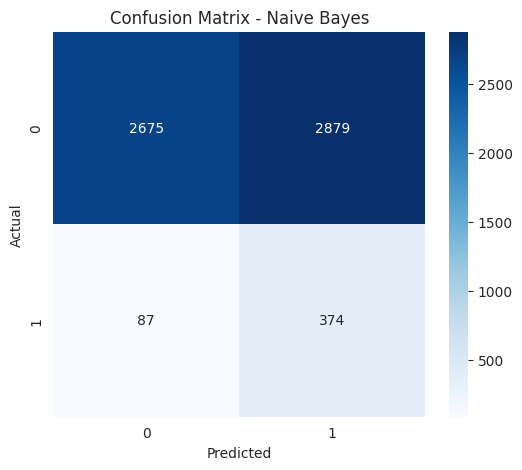

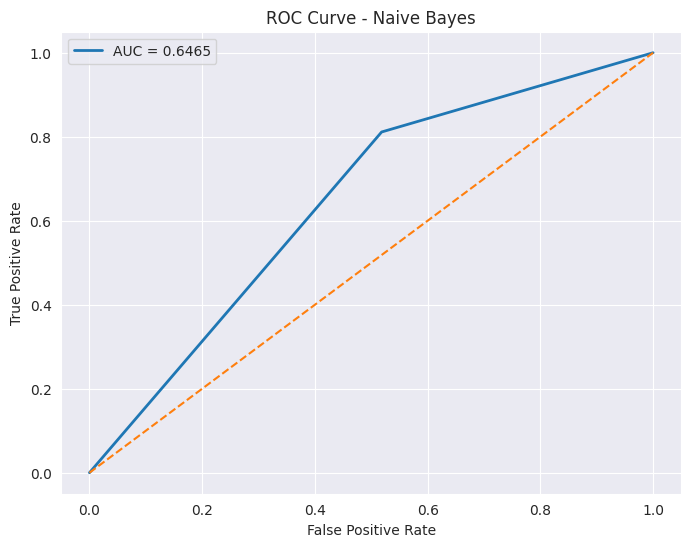


KNN

Accuracy Score : 0.9709

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5554
           1       0.88      0.72      0.79       461

    accuracy                           0.97      6015
   macro avg       0.93      0.85      0.89      6015
weighted avg       0.97      0.97      0.97      6015



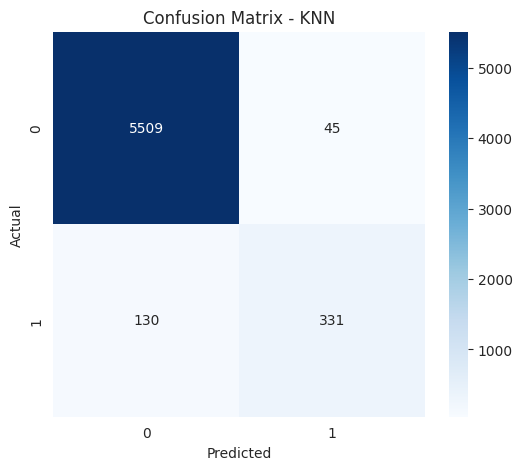

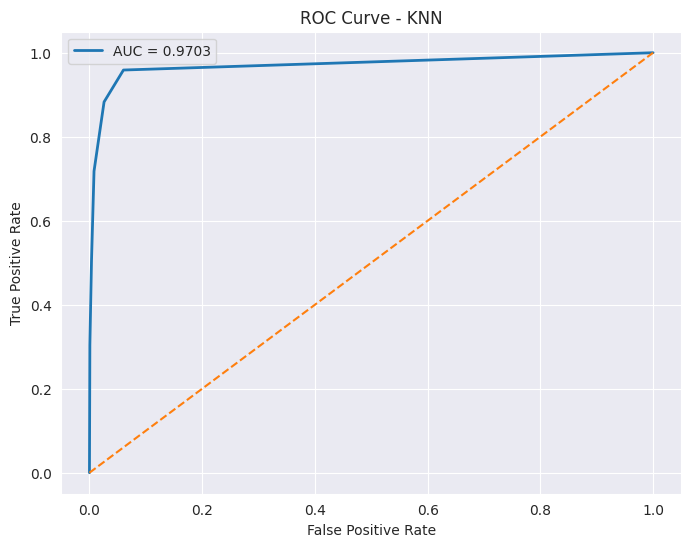


SVM

Accuracy Score : 0.9905

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5554
           1       0.94      0.93      0.94       461

    accuracy                           0.99      6015
   macro avg       0.97      0.97      0.97      6015
weighted avg       0.99      0.99      0.99      6015



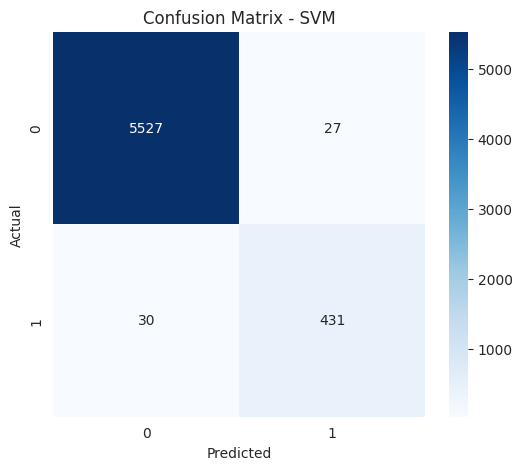

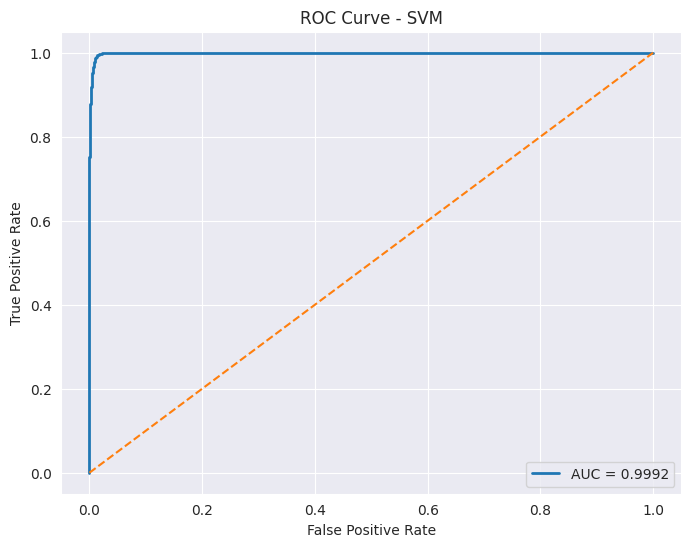


FINAL MODEL RESULTS
                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.994514  0.999757
1        Decision Tree  1.000000  1.000000
2        Random Forest  0.998504  0.999992
3          Naive Bayes  0.506899  0.646457
4                  KNN  0.970906  0.970274
5                  SVM  0.990524  0.999225

BEST MODEL
Model       Decision Tree
Accuracy              1.0
ROC_AUC               1.0
Name: 1, dtype: object


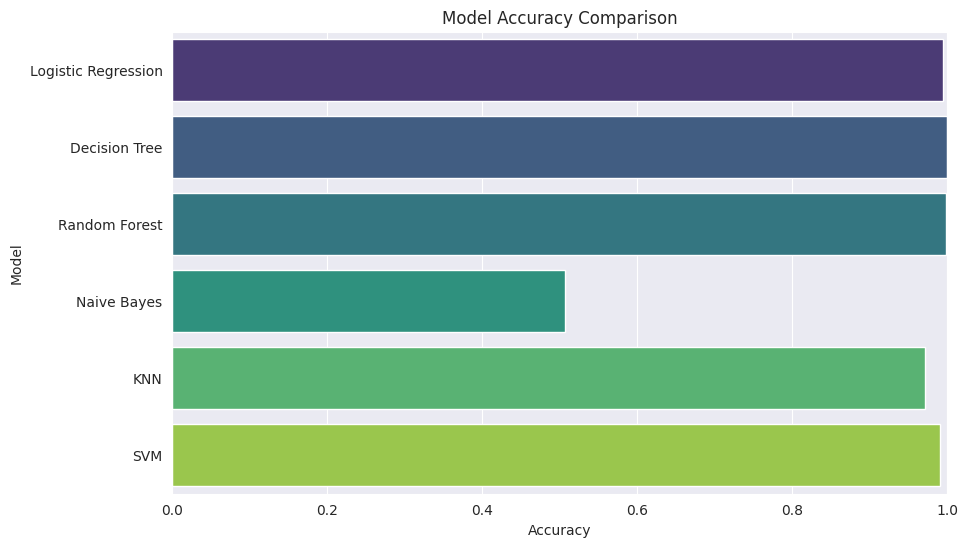

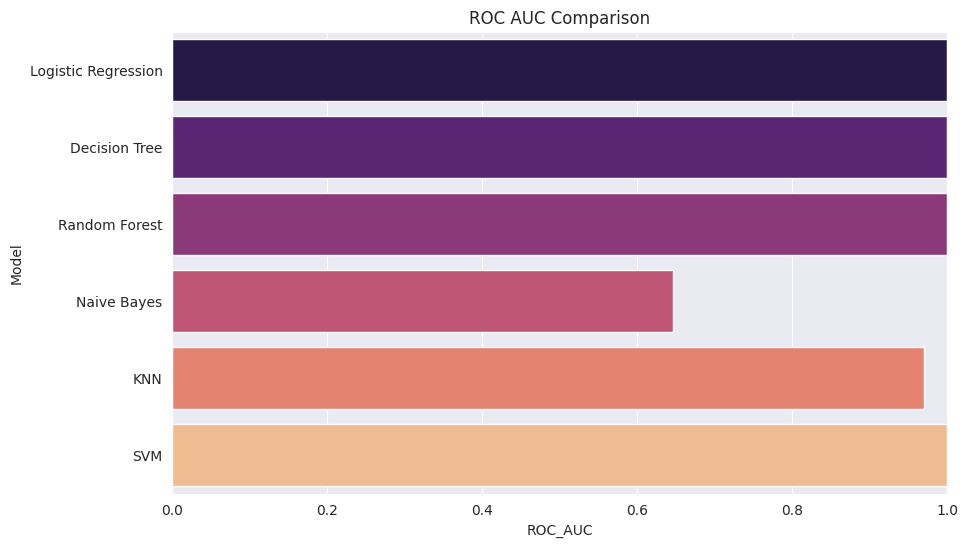


FEATURE IMPORTANCE
                                    Feature  Importance
1                                     score    0.276264
3                                      rank    0.197449
6                                 favorites    0.062385
5                                   members    0.058133
2                                 scored_by    0.040434
4                                popularity    0.034666
0                                  episodes    0.008945
4682                          producers_NHK    0.008430
8857                      demographics_Kids    0.007133
7                                      year    0.006661
23                             source_Manga    0.006293
8863                   demographics_Shounen    0.005573
6941                   licensors_Funimation    0.005544
2035                        studios_Unknown    0.005011
8672                           themes_Music    0.004655
372        rating_PG-13 - Teens 13 or older    0.003896
373   rating_R - 17+ (violen

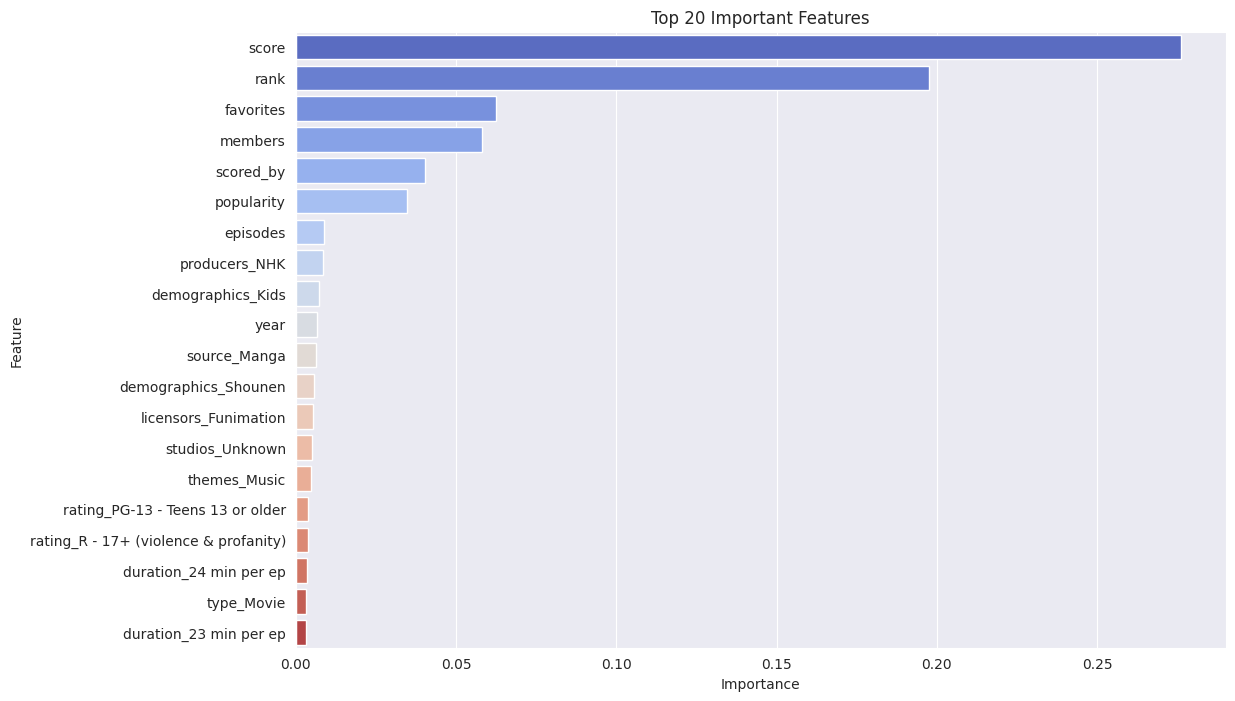

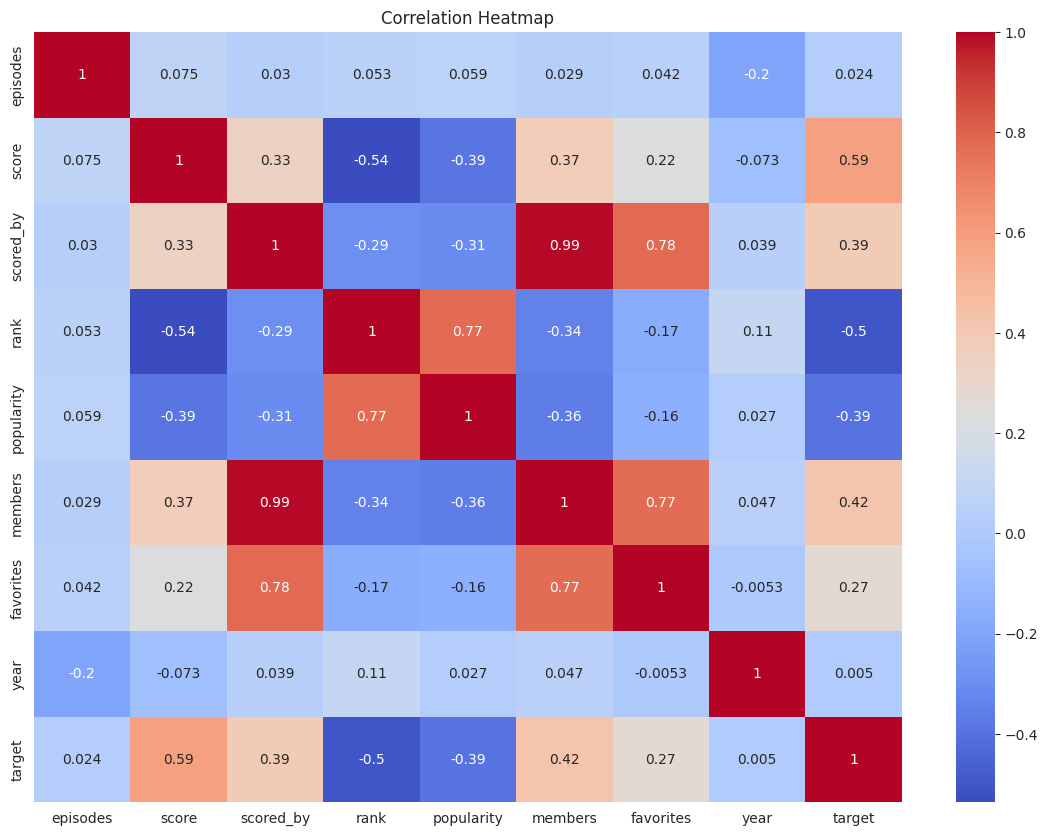


ANIME MACHINE LEARNING PROJECT COMPLETED


In [14]:
# ============================================================
# COMPLETE ANIME MACHINE LEARNING PROJECT
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)



# HIGH RATED = 1
# LOW RATED  = 0

df['target'] = np.where(df['score'] >= 7.5, 1, 0)

print("\n" + "="*70)
print("TARGET VALUE COUNTS")
print("="*70)

print(df['target'].value_counts())

# ============================================================
# DROP USELESS COLUMNS
# ============================================================

drop_cols = [
    'mal_id',
    'title',
    'title_english',
    'title_japanese',
    'synopsis',
    'image_url',
    'aired_from',
    'aired_to'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop('target', axis=1)
y = df['target']

print("\nFeature Shape :", X.shape)
print("Target Shape  :", y.shape)

# ============================================================
# NUMERICAL & CATEGORICAL COLUMNS
# ============================================================

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = X.select_dtypes(
    include=['object', 'bool']
).columns

print("\n" + "="*70)
print("NUMERICAL COLUMNS")
print("="*70)

print(numerical_cols)

print("\n" + "="*70)
print("CATEGORICAL COLUMNS")
print("="*70)

print(categorical_cols)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# IMPORTANT:
# SPLIT BEFORE PREPROCESSING
# TO AVOID DATA LEAKAGE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
# sparse_output=False fixes GaussianNB error

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    
    "Naive Bayes": GaussianNB(),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(
        probability=True
    )
}

# ============================================================
# RESULTS STORAGE
# ============================================================

results = []

# ============================================================
# TRAINING LOOP
# ============================================================

for model_name, model in models.items():

    print("\n" + "="*70)
    print(f"{model_name}")
    print("="*70)

    # ========================================================
    # CREATE PIPELINE
    # ========================================================

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    pipeline.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = pipeline.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    y_prob = pipeline.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {auc_score:.4f}"
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend()

    plt.show()

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score
    })

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("FINAL MODEL RESULTS")
print("="*70)

print(results_df)

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n" + "="*70)
print("BEST MODEL")
print("="*70)

print(best_model)

# ============================================================
# ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison")
plt.xlim(0,1)

plt.show()

# ============================================================
# ROC AUC COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Comparison")
plt.xlim(0,1)

plt.show()

# ============================================================
# FEATURE IMPORTANCE USING RANDOM FOREST
# ============================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

# Preprocess data
X_train_processed = preprocessor.fit_transform(X_train)

# Train Random Forest separately
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

# Get encoded categorical feature names
encoded_cat_features = preprocessor.named_transformers_[
    'cat'
].named_steps[
    'encoder'
].get_feature_names_out(categorical_cols)

# Combine all feature names
all_features = np.concatenate([
    numerical_cols,
    encoded_cat_features
])

# Importance dataframe
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(importance_df)

# ============================================================
# FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='coolwarm'
)

plt.title("Top 20 Important Features")

plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# COMPLETED
# ============================================================

print("\n" + "="*70)
print("ANIME MACHINE LEARNING PROJECT COMPLETED")
print("="*70)

## Thank you..pls upvote!!!!!!!!!!